The goal of this project is to build a machine learning model to predict **agricultural irrigation needs** categorized as:

- **Low**
- **Medium**
- **High**

We use **Macro F1-Score** as the primary evaluation metric.

- The dataset is **highly imbalanced**, with the `High` irrigation class representing only **~3.3%** of the data.
- Treats all classes **equally**, regardless of their frequency  
- Penalizes poor performance on minority classes  


## Imports

In [1]:
import pandas as pd 
import numpy as np 
import os 

import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)
import random
random.seed(SEED)

plt.rcParams['figure.figsize'] = (10 , 6)
plt.rcParams['axes.titlesize'] = 14
sns.set_theme(style = "whitegrid")

import warnings 
warnings.filterwarnings('ignore')

## Data Loading

In [2]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print(train_df.shape)

print(test_df.shape)

(630000, 21)
(270000, 20)


In [3]:
train_df.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [4]:
test_df.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,630000,Silt,6.36,26.19,0.59,2.81,17.83,30.24,1533.38,5.40,3.00,Maize,Sowing,Rabi,Canal,River,13.59,Yes,47.48,West
1,630001,Clay,5.87,9.88,1.18,3.26,21.18,78.07,576.05,7.22,15.88,Cotton,Sowing,Rabi,Drip,Reservoir,6.12,Yes,56.43,South
2,630002,Sandy,6.22,26.55,0.96,0.85,26.87,60.35,545.30,9.43,2.63,Wheat,Sowing,Kharif,Sprinkler,Reservoir,3.11,Yes,20.00,East
3,630003,Clay,7.68,53.58,0.83,0.55,41.74,36.05,1211.03,6.69,1.86,Maize,Harvest,Rabi,Canal,Groundwater,2.27,No,102.99,North
4,630004,Loamy,5.23,59.02,0.54,2.11,41.08,52.47,1321.91,4.11,5.71,Cotton,Sowing,Kharif,Canal,Groundwater,12.39,Yes,13.33,Central


In [5]:
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [6]:
train_df.isnull().sum()

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

In [7]:
print(test_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       270000 non-null  int64  
 1   Soil_Type                270000 non-null  object 
 2   Soil_pH                  270000 non-null  float64
 3   Soil_Moisture            270000 non-null  float64
 4   Organic_Carbon           270000 non-null  float64
 5   Electrical_Conductivity  270000 non-null  float64
 6   Temperature_C            270000 non-null  float64
 7   Humidity                 270000 non-null  float64
 8   Rainfall_mm              270000 non-null  float64
 9   Sunlight_Hours           270000 non-null  float64
 10  Wind_Speed_kmh           270000 non-null  float64
 11  Crop_Type                270000 non-null  object 
 12  Crop_Growth_Stage        270000 non-null  object 
 13  Season                   270000 non-null  object 
 14  Irri

In [8]:
test_df.isnull().sum()

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
dtype: int64

We have 9 text-based columns ... Machine learning models strictly require numbers ... So a major part of our preprocessing step will be translating these text categories into numbers ...
<br>
The id column is just a row identifier ... We'll need to drop this before training otherwise the model might try to learn a pattern based on the row number ...

## EDA

In [10]:
target_dist = train_df['Irrigation_Need'].value_counts(normalize = True) * 100

In [11]:
display(target_dist)

Irrigation_Need
Low       58.716984
Medium    37.948254
High       3.334762
Name: proportion, dtype: float64

We will see if the data set is balanced by using value_counts and setting the normalize parameter to 1 

Your target variable is highly imbalanced 
<br> 
Only 3 percent is Hard
<br> 
We have to use Macro F1 for Evaluation

In [14]:
categorical_cols = train_df.select_dtypes(include = ['object']).columns

In [15]:
for cols in categorical_cols :
    unique_counts = train_df[cols].nunique()
    print(f"{cols} has {unique_counts} counts")

Soil_Type has 4 counts
Crop_Type has 6 counts
Crop_Growth_Stage has 4 counts
Season has 3 counts
Irrigation_Type has 4 counts
Water_Source has 4 counts
Mulching_Used has 2 counts
Region has 5 counts
Irrigation_Need has 3 counts


We will check that what is the cardianality of the set wheather we can Encode it into 4 5 variables 

We will use statified Split for Validation for Unbalanced Distribution 

In [18]:
from sklearn.model_selection import train_test_split

train_df = train_df.drop('id' , axis = 1)
test_ids = test_df['id']
test_df = test_df.drop('id' , axis = 1)

target_mapping = {"Low" : 0 , "Medium" : 1 , "High" : 2}
train_df['Irrigation_Need'] = train_df['Irrigation_Need'].map(target_mapping)

X = train_df.drop('Irrigation_Need' , axis = 1)
y = train_df['Irrigation_Need']

X_train , X_val , y_train , y_val = train_test_split(
    X , y , 
    test_size = 0.20 , 
    random_state = SEED , 
    stratify = y 
)

Now we are going to apply One Hot Encoding to Categorical Data Columns <br>
And Apply Scaling to the different Numerical Values

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler , OneHotEncoder

numerical_cols = X_train.select_dtypes(include = ['int64' , 'float64']).columns

categorical_cols = X_train.select_dtypes(include = ['object']).columns

print(len(numerical_cols) + len(categorical_cols))

19


In [21]:
numerical_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(handle_unknown = 'ignore' , sparse_output = False)

preprocessor = ColumnTransformer(
    transformers = [
        ('num' , numerical_transformer , numerical_cols) , 
        ('cat' , categorical_transformer , categorical_cols)
    ])

X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)

print(X_train.shape)
print(X_train_processed.shape)

(504000, 19)
(504000, 43)


We will use Random Forest as our Baseline Model As It is stable to Overfitting And Requires Less Hyperparameter tuning 

## Random Forest 

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report , f1_score

rf_model = RandomForestClassifier(
    n_estimators = 100 , 
    random_state = SEED , 
    class_weight = 'balanced' ,
    n_jobs = - 1 
)

rf_model.fit(X_train_processed , y_train)

val_predictions = rf_model.predict(X_val_processed)

print(classification_report(y_val , val_predictions , target_names = ['Low(0)' , 'Medium(1)' , 'High(2)']))

macro_f1 = f1_score(y_val , val_predictions , average = 'macro')

print(macro_f1)

              precision    recall  f1-score   support

      Low(0)       0.99      1.00      0.99     73983
   Medium(1)       0.98      0.98      0.98     47815
     High(2)       0.98      0.88      0.93      4202

    accuracy                           0.98    126000
   macro avg       0.98      0.95      0.97    126000
weighted avg       0.98      0.98      0.98    126000

0.9661929724289088


Good f1 score denotes clean and predictive data

Lets See the Important Feature Columns 

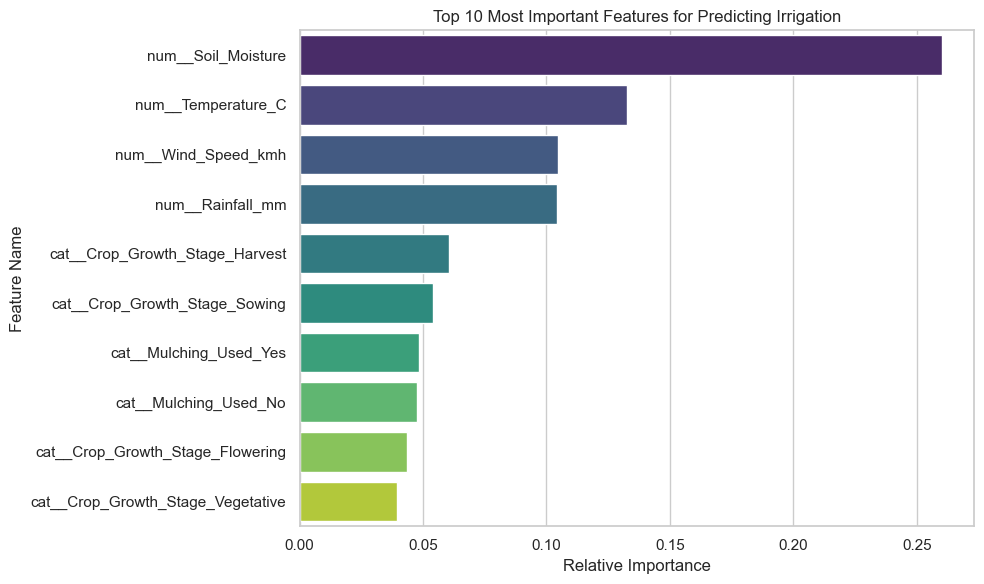

In [25]:
importances = rf_model.feature_importances_
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Most Important Features for Predicting Irrigation')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()


X_test_processed = preprocessor.transform(test_df)

test_predictions = rf_model.predict(X_test_processed)

reverse_mapping = {0: 'Low', 1: 'Medium', 2: 'High'}
final_text_predictions = pd.Series(test_predictions).map(reverse_mapping)

submission_df = pd.DataFrame({
    'id': test_ids,
    'Irrigation_Need': final_text_predictions
})

submission_df.to_csv('submission.csv', index=False)

Upto Now we Tried Random Forest for Stability <br>
Now Going to Catboost to Use the Categorical Columns 

## CatBoost

In [26]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, f1_score

cb_model = CatBoostClassifier(
    iterations=500,               
    random_seed=SEED,
    auto_class_weights='Balanced',  
    verbose=100                    
)

cb_model.fit(
    X_train_processed, y_train, 
    eval_set=(X_val_processed, y_val), 
    early_stopping_rounds=50
)
print("Complete Training")
val_predictions_cb = cb_model.predict(X_val_processed)


print(classification_report(y_val, val_predictions_cb, target_names=['Low (0)', 'Medium (1)', 'High (2)']))

macro_f1_cb = f1_score(y_val, val_predictions_cb, average='macro')
print(f"Overall CatBoost Macro F1-Score: {macro_f1_cb:.4f}")

Learning rate set to 0.159357
0:	learn: 0.8632824	test: 0.8635584	best: 0.8635584 (0)	total: 169ms	remaining: 1m 24s
100:	learn: 0.0913355	test: 0.0997309	best: 0.0997309 (100)	total: 7.02s	remaining: 27.7s
200:	learn: 0.0805406	test: 0.0952462	best: 0.0952462 (200)	total: 13.9s	remaining: 20.6s
300:	learn: 0.0730684	test: 0.0928549	best: 0.0928343 (291)	total: 19.9s	remaining: 13.2s
400:	learn: 0.0680076	test: 0.0925424	best: 0.0924315 (373)	total: 25.9s	remaining: 6.4s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.09243145888
bestIteration = 373

Shrink model to first 374 iterations.
Complete Training
              precision    recall  f1-score   support

     Low (0)       0.99      0.99      0.99     73983
  Medium (1)       0.98      0.97      0.98     47815
    High (2)       0.87      0.94      0.91      4202

    accuracy                           0.98    126000
   macro avg       0.95      0.97      0.96    126000
weighted avg       0.98      0.98      0.

In [40]:
categorical_features = list(X_train.select_dtypes(include=['object']).columns)

print(f"Telling CatBoost to use its native engine on these columns: {categorical_features}\n")


cb_model_native = CatBoostClassifier(
    iterations=500,
    random_seed=SEED,
    auto_class_weights='Balanced',
    cat_features=categorical_features,
    verbose=100
)

cb_model_native.fit(
    X_train, y_train,                  
    eval_set=(X_val, y_val),          
    early_stopping_rounds=50
)
print("Training complete")

val_predictions_cb_native = cb_model_native.predict(X_val)

macro_f1_cb_native = f1_score(y_val, val_predictions_cb_native, average='macro')
print(f"Overall Native CatBoost Macro F1-Score : {macro_f1_cb_native}")

Telling CatBoost to use its native engine on these columns: ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']

Learning rate set to 0.159357
0:	learn: 0.8347963	test: 0.8354809	best: 0.8354809 (0)	total: 1.07s	remaining: 8m 52s
100:	learn: 0.0910875	test: 0.0987270	best: 0.0987270 (100)	total: 1m 36s	remaining: 6m 22s
200:	learn: 0.0805178	test: 0.0936184	best: 0.0936160 (199)	total: 3m 14s	remaining: 4m 49s
300:	learn: 0.0747000	test: 0.0923412	best: 0.0923412 (300)	total: 4m 51s	remaining: 3m 12s
400:	learn: 0.0700054	test: 0.0917578	best: 0.0917303 (399)	total: 6m 23s	remaining: 1m 34s
499:	learn: 0.0660225	test: 0.0913649	best: 0.0912984 (472)	total: 7m 56s	remaining: 0us

bestTest = 0.09129835344
bestIteration = 472

Shrink model to first 473 iterations.
Training complete
Overall Native CatBoost Macro F1-Score : 0.9574848842643653


## Feature Engineering

Lets try by adding a few more Columns hoping CatBoost to perform better

We are creating a 'Moisture_Stress' feature because the interaction between temperature and existing soil moisture is often a better predictor of crop health than either variable alone

In [42]:
def engineer_features(df):
    df = df.copy()
    
    df['Total_Water_Input'] = df['Rainfall_mm'] + df['Previous_Irrigation_mm']

    df['Evaporation_Proxy'] = (df['Temperature_C'] * df['Sunlight_Hours']) / (df['Humidity'] + 1e-5)
    
    df['Moisture_Stress'] = df['Temperature_C'] / (df['Soil_Moisture'] + 1e-5)
    
    return df


X_train_eng = engineer_features(X_train)
X_val_eng = engineer_features(X_val)
test_df_eng = engineer_features(test_df)


categorical_features = list(X_train_eng.select_dtypes(include=['object']).columns)

cb_model_eng = CatBoostClassifier(
    iterations=500,
    random_seed=SEED,
    auto_class_weights='Balanced',
    cat_features=categorical_features,
    verbose=100
)

cb_model_eng.fit(
    X_train_eng, y_train,            
    eval_set=(X_val_eng, y_val),           
    early_stopping_rounds=50
)

val_predictions_cb_eng = cb_model_eng.predict(X_val_eng)

macro_f1_cb_eng = f1_score(y_val, val_predictions_cb_eng, average='macro')
print(f"Overall Engineered CatBoost Macro F1-Score: {macro_f1_cb_eng:.4f}")

Learning rate set to 0.159357
0:	learn: 0.8371376	test: 0.8378199	best: 0.8378199 (0)	total: 964ms	remaining: 8m 1s
100:	learn: 0.0916156	test: 0.0997551	best: 0.0997349 (99)	total: 1m 27s	remaining: 5m 46s
200:	learn: 0.0813594	test: 0.0949304	best: 0.0949304 (200)	total: 3m 3s	remaining: 4m 32s
300:	learn: 0.0747342	test: 0.0933946	best: 0.0933946 (300)	total: 4m 50s	remaining: 3m 11s
400:	learn: 0.0700340	test: 0.0925410	best: 0.0925001 (397)	total: 6m 37s	remaining: 1m 38s
499:	learn: 0.0659030	test: 0.0924829	best: 0.0923684 (461)	total: 8m 33s	remaining: 0us

bestTest = 0.09236835847
bestIteration = 461

Shrink model to first 462 iterations.
Overall Engineered CatBoost Macro F1-Score: 0.9588


Let's Blender Them  

## Blending

In [45]:
import numpy as np

rf_probabilities = rf_model.predict_proba(X_val_processed)

cb_probabilities = cb_model_eng.predict_proba(X_val_eng)

blended_probabilities = (rf_probabilities + cb_probabilities) / 2.0

blended_predictions = np.argmax(blended_probabilities, axis=1)

print(classification_report(y_val, blended_predictions, target_names=['Low (0)', 'Medium (1)', 'High (2)']))

macro_f1_blend = f1_score(y_val, blended_predictions, average='macro')
print(f"Overall Blended Macro F1-Score: {macro_f1_blend:.4f}")

              precision    recall  f1-score   support

     Low (0)       0.99      0.99      0.99     73983
  Medium (1)       0.98      0.97      0.98     47815
    High (2)       0.95      0.92      0.93      4202

    accuracy                           0.98    126000
   macro avg       0.97      0.96      0.97    126000
weighted avg       0.98      0.98      0.98    126000

Overall Blended Macro F1-Score: 0.9679


In [47]:
rf_test_probs = rf_model.predict_proba(X_test_processed)


cb_test_probs = cb_model_eng.predict_proba(test_df_eng)

blended_test_probs = (rf_test_probs + cb_test_probs) / 2.0

blended_test_predictions = np.argmax(blended_test_probs, axis=1)

final_blended_text = pd.Series(blended_test_predictions).map(reverse_mapping)

submission_blend_df = pd.DataFrame({
    'id': test_ids,
    'Irrigation_Need': final_blended_text
})

submission_blend_df.to_csv('submission_blended.csv', index=False)
print("Submission")

Submission


Using Optimal Blend Weights

In [50]:
import numpy as np
from sklearn.metrics import f1_score


best_score = 0
best_w = 0

for w in np.linspace(0, 1, 101):
    test_blend_probs = (w * rf_probabilities) + ((1 - w) * cb_probabilities)
    
    test_preds = np.argmax(test_blend_probs, axis=1)

    current_score = f1_score(y_val, test_preds, average='macro')
    
    if current_score > best_score:
        best_score = current_score
        best_w = w

print(f"Optimal Random Forest Weight: {best_w:.2f} ({(best_w * 100):.0f}%)")
print(f"Optimal CatBoost Weight:      {(1 - best_w):.2f} ({((1 - best_w) * 100):.0f}%)")
print(f"New Maximized F1-Score:       {best_score:.4f}")


Optimal Random Forest Weight: 0.72 (72%)
Optimal CatBoost Weight:      0.28 (28%)
New Maximized F1-Score:       0.9693


In [51]:

weight_rf = 0.72
weight_cb = 0.28


rf_test_probs = rf_model.predict_proba(X_test_processed)


cb_test_probs = cb_model_eng.predict_proba(test_df_eng)

optimized_test_probs = (weight_rf * rf_test_probs) + (weight_cb * cb_test_probs)

optimized_test_predictions = np.argmax(optimized_test_probs, axis=1)

reverse_mapping = {0: 'Low', 1: 'Medium', 2: 'High'}
final_optimized_text = pd.Series(optimized_test_predictions).map(reverse_mapping)

submission_opt_df = pd.DataFrame({
    'id': test_ids,
    'Irrigation_Need': final_optimized_text
})

submission_opt_df.to_csv('submission_optimized_blend.csv', index=False)
print("Submission")

Submission


## 5 Fold Validation Of Catboost

In [52]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


oof_predictions = np.zeros(len(X_train_eng)) 
test_predictions_list = []                   
fold_scores = []                             


categorical_features = list(X_train_eng.select_dtypes(include=['object']).columns)


for fold, (train_index, val_index) in enumerate(skf.split(X_train_eng, y_train)):
    print(f"\n Training Fold {fold + 1} / 5")
    
    X_fold_train, X_fold_val = X_train_eng.iloc[train_index], X_train_eng.iloc[val_index]
    
    y_fold_train, y_fold_val = y_train.iloc[train_index], y_train.iloc[val_index]
    
    model = CatBoostClassifier(
        iterations=500,
        random_seed=SEED,
        auto_class_weights='Balanced',
        cat_features=categorical_features,
        verbose=0 
    )
    
    model.fit(
        X_fold_train, y_fold_train, 
        eval_set=(X_fold_val, y_fold_val), 
        early_stopping_rounds=50
    )
    
    val_preds = model.predict(X_fold_val)
    oof_predictions[val_index] = val_preds.flatten() 
    
    fold_f1 = f1_score(y_fold_val, val_preds, average='macro')
    fold_scores.append(fold_f1)
    print(f"Fold {fold + 1} Macro F1: {fold_f1:.4f}")
    
    test_preds = model.predict_proba(test_df_eng)
    test_predictions_list.append(test_preds)


overall_oof_score = f1_score(y_train, oof_predictions, average='macro')
print(f"Average Fold Score: {np.mean(fold_scores):.4f} (±{np.std(fold_scores):.4f})")
print(f"OVERALL True CV Score: {overall_oof_score:.4f}")


 Training Fold 1 / 5
Fold 1 Macro F1: 0.9591

 Training Fold 2 / 5
Fold 2 Macro F1: 0.9591

 Training Fold 3 / 5
Fold 3 Macro F1: 0.9604

 Training Fold 4 / 5
Fold 4 Macro F1: 0.9584

 Training Fold 5 / 5
Fold 5 Macro F1: 0.9608
Average Fold Score: 0.9596 (±0.0009)
OVERALL True CV Score: 0.9596


Initiating Baysian Optimisation using Optuna

## Using Optuna ( Bayesian ) for finding optimal Parameters

In [60]:
import optuna
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import f1_score


X_opt_train, X_opt_val, y_opt_train, y_opt_val = train_test_split(
    X_train_eng, y_train, test_size=0.2, stratify=y_train, random_state=SEED
)

def objective(trial):
    params = {
        'iterations': 500,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'random_seed': SEED,
        'auto_class_weights': 'Balanced',
        'cat_features': categorical_features,
        'verbose': 0
    }
    
    model = CatBoostClassifier(**params)
    model.fit(
        X_opt_train, y_opt_train, 
        eval_set=(X_opt_val, y_opt_val), 
        early_stopping_rounds=50
    )
    
    preds = model.predict(X_opt_val)
    return f1_score(y_opt_val, preds, average='macro')

# Create the study and run 20 trials
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

print(f"Best Macro F1-Score Found: {study.best_value:.4f}")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"    '{key}': {value}")

[I 2026-04-10 12:51:07,823] A new study created in memory with name: no-name-6044dd11-90ed-4997-bec2-cef5907aedfa
[I 2026-04-10 12:59:06,359] Trial 0 finished with value: 0.962210029853486 and parameters: {'learning_rate': 0.08344086551406739, 'depth': 9, 'l2_leaf_reg': 0.0030638781942342827}. Best is trial 0 with value: 0.962210029853486.
[I 2026-04-10 13:13:36,356] Trial 1 finished with value: 0.9612016076372082 and parameters: {'learning_rate': 0.02946131248091872, 'depth': 10, 'l2_leaf_reg': 0.012018035233273335}. Best is trial 0 with value: 0.962210029853486.
[I 2026-04-10 13:25:41,541] Trial 2 finished with value: 0.9605692951238067 and parameters: {'learning_rate': 0.03479926956034179, 'depth': 9, 'l2_leaf_reg': 0.10981011902886627}. Best is trial 0 with value: 0.962210029853486.
[I 2026-04-10 13:29:23,087] Trial 3 finished with value: 0.9561612372893596 and parameters: {'learning_rate': 0.28025203736253057, 'depth': 7, 'l2_leaf_reg': 2.5363434149975457}. Best is trial 0 with va

Best Macro F1-Score Found: 0.9627
Best Hyperparameters:
    'learning_rate': 0.043862100116077156
    'depth': 10
    'l2_leaf_reg': 0.002788087780383213


Using the parameters to determined by Optuna

In [62]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from catboost import CatBoostClassifier

optuna_params = {
    'iterations': 1000,
    'learning_rate': 0.07177388680397115,
    'depth': 9,
    'l2_leaf_reg': 0.3001140213341316,
    'random_seed': SEED,
    'auto_class_weights': 'Balanced',
    'cat_features': categorical_features,
    'verbose': 0
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

oof_predictions = np.zeros(len(X_train_eng)) 
test_predictions_list = []                   
fold_scores = []                             

for fold, (train_index, val_index) in enumerate(skf.split(X_train_eng, y_train)):
    print(f"Training Fold {fold + 1} / 5 ")
    
    X_fold_train, X_fold_val = X_train_eng.iloc[train_index], X_train_eng.iloc[val_index]
    y_fold_train, y_fold_val = y_train.iloc[train_index], y_train.iloc[val_index]
    
    model = CatBoostClassifier(**optuna_params)
    

    model.fit(
        X_fold_train, y_fold_train, 
        eval_set=(X_fold_val, y_fold_val), 
        early_stopping_rounds=50 
    )
    

    val_preds = model.predict(X_fold_val)
    oof_predictions[val_index] = val_preds.flatten() 

    fold_f1 = f1_score(y_fold_val, val_preds, average='macro')
    fold_scores.append(fold_f1)
    print(f"    Fold {fold + 1} Score: {fold_f1:.4f}")
    
    test_preds = model.predict_proba(test_df_eng)
    test_predictions_list.append(test_preds)

overall_oof_score = f1_score(y_train, oof_predictions, average='macro')
print(f"Average Fold Score: {np.mean(fold_scores):.4f} (±{np.std(fold_scores):.4f})")
print(f"OVERALL True CV Score: {overall_oof_score:.4f}")

average_test_probs = np.mean(test_predictions_list, axis=0)


final_test_predictions = np.argmax(average_test_probs, axis=1)

reverse_mapping = {0: 'Low', 1: 'Medium', 2: 'High'}
final_text_predictions = pd.Series(final_test_predictions).map(reverse_mapping)

submission_final_df = pd.DataFrame({
    'id': test_ids,
    'Irrigation_Need': final_text_predictions
})

submission_final_df.to_csv('submission_optuna_5fold.csv', index=False)
print("Submission")

Training Fold 1 / 5 
    Fold 1 Score: 0.9604
Training Fold 2 / 5 
    Fold 2 Score: 0.9626
Training Fold 3 / 5 
    Fold 3 Score: 0.9619
Training Fold 4 / 5 
    Fold 4 Score: 0.9578
Training Fold 5 / 5 
    Fold 5 Score: 0.9625
Average Fold Score: 0.9611 (±0.0018)
OVERALL True CV Score: 0.9610
Submission


## Advanced Feature Engineering

In [63]:
def engineer_advanced_features(df):
    df = df.copy()
    
    df['Total_Water_Input'] = df['Rainfall_mm'] + df['Previous_Irrigation_mm']
    df['Evaporation_Proxy'] = (df['Temperature_C'] * df['Sunlight_Hours']) / (df['Humidity'] + 1e-5)
    df['Moisture_Stress'] = df['Temperature_C'] / (df['Soil_Moisture'] + 1e-5)
    
    df['Crop_Soil_Combo'] = df['Crop_Type'].astype(str) + "_" + df['Soil_Type'].astype(str)
    
    df['Crop_Stage_Combo'] = df['Crop_Type'].astype(str) + "_" + df['Crop_Growth_Stage'].astype(str)
    
    df['Region_Season_Combo'] = df['Region'].astype(str) + "_" + df['Season'].astype(str)
    
    return df

X_train_adv = engineer_advanced_features(X_train)
test_df_adv = engineer_advanced_features(test_df)


advanced_categorical_features = list(X_train_adv.select_dtypes(include=['object']).columns)
print(f"New Categorical Features for CatBoost: \n{advanced_categorical_features}")

New Categorical Features for CatBoost: 
['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region', 'Crop_Soil_Combo', 'Crop_Stage_Combo', 'Region_Season_Combo']


In [64]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from catboost import CatBoostClassifier

optuna_params = {
    'iterations': 1000, 
    'learning_rate': 0.07177388680397115,
    'depth': 9,
    'l2_leaf_reg': 0.3001140213341316,
    'random_seed': SEED,
    'auto_class_weights': 'Balanced',
    'cat_features': advanced_categorical_features,
    'verbose': 0
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

oof_predictions = np.zeros(len(X_train_adv)) 
test_predictions_list = []                   
fold_scores = []                             

for fold, (train_index, val_index) in enumerate(skf.split(X_train_adv, y_train)):
    print(f"Training Fold {fold + 1} / 5")
    
    X_fold_train, X_fold_val = X_train_adv.iloc[train_index], X_train_adv.iloc[val_index]
    y_fold_train, y_fold_val = y_train.iloc[train_index], y_train.iloc[val_index]
    
    model = CatBoostClassifier(**optuna_params)
    
    model.fit(
        X_fold_train, y_fold_train, 
        eval_set=(X_fold_val, y_fold_val), 
        early_stopping_rounds=50 
    )
    
    val_preds = model.predict(X_fold_val)
    oof_predictions[val_index] = val_preds.flatten() 
    
    fold_f1 = f1_score(y_fold_val, val_preds, average='macro')
    fold_scores.append(fold_f1)
    print(f"    Fold {fold + 1} Score: {fold_f1:.4f}")
    
    test_preds = model.predict_proba(test_df_adv)
    test_predictions_list.append(test_preds)

overall_oof_score = f1_score(y_train, oof_predictions, average='macro')
print(f"Average Fold Score: {np.mean(fold_scores):.4f} (±{np.std(fold_scores):.4f})")
print(f"OVERALL True CV Score: {overall_oof_score:.4f}")


average_test_probs = np.mean(test_predictions_list, axis=0)

final_test_predictions = np.argmax(average_test_probs, axis=1)

reverse_mapping = {0: 'Low', 1: 'Medium', 2: 'High'}
final_text_predictions = pd.Series(final_test_predictions).map(reverse_mapping)

submission_final_adv_df = pd.DataFrame({
    'id': test_ids,
    'Irrigation_Need': final_text_predictions
})

submission_final_adv_df.to_csv('submission_new_features.csv', index=False)
print("Submission")

Training Fold 1 / 5
    Fold 1 Score: 0.9604
Training Fold 2 / 5
    Fold 2 Score: 0.9621
Training Fold 3 / 5
    Fold 3 Score: 0.9627
Training Fold 4 / 5
    Fold 4 Score: 0.9594
Training Fold 5 / 5
    Fold 5 Score: 0.9626
Average Fold Score: 0.9614 (±0.0013)
OVERALL True CV Score: 0.9614
Submission


## Triblend Meta Learner ( Stacking )

In [65]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

X_train_adv_encoded = pd.get_dummies(X_train_adv)
test_df_adv_encoded = pd.get_dummies(test_df_adv)

X_train_adv_encoded, test_df_adv_encoded = X_train_adv_encoded.align(
    test_df_adv_encoded, join='left', axis=1, fill_value=0
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

rf_oof = np.zeros((len(X_train_adv), 3))
cb_oof = np.zeros((len(X_train_adv), 3))
lgb_oof = np.zeros((len(X_train_adv), 3))

rf_test_preds = []
cb_test_preds = []
lgb_test_preds = []

for fold, (train_index, val_index) in enumerate(skf.split(X_train_adv, y_train)):
    print(f"\nTraining Fold {fold + 1} / 5")
    
    X_cb_train, X_cb_val = X_train_adv.iloc[train_index], X_train_adv.iloc[val_index]
    
    X_rf_train, X_rf_val = X_train_adv_encoded.iloc[train_index], X_train_adv_encoded.iloc[val_index]
    
    y_fold_train, y_fold_val = y_train.iloc[train_index], y_train.iloc[val_index]
    
    print("  -> Random Forest")
    rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=SEED, n_jobs=-1)
    rf.fit(X_rf_train, y_fold_train)
    rf_oof[val_index] = rf.predict_proba(X_rf_val)
    rf_test_preds.append(rf.predict_proba(test_df_adv_encoded))
    
    print("  -> CatBoost")
    cb = CatBoostClassifier(**optuna_params)
    cb.fit(X_cb_train, y_fold_train, eval_set=(X_cb_val, y_fold_val), early_stopping_rounds=50, verbose=0)
    cb_oof[val_index] = cb.predict_proba(X_cb_val)
    cb_test_preds.append(cb.predict_proba(test_df_adv))
    
    print("  -> LightGBM")
    lgb = LGBMClassifier(n_estimators=500, learning_rate=0.05, class_weight='balanced', random_state=SEED, verbose=-1)
    lgb.fit(X_rf_train, y_fold_train) 
    lgb_oof[val_index] = lgb.predict_proba(X_rf_val)
    lgb_test_preds.append(lgb.predict_proba(test_df_adv_encoded))

rf_test_final = np.mean(rf_test_preds, axis=0)
cb_test_final = np.mean(cb_test_preds, axis=0)
lgb_test_final = np.mean(lgb_test_preds, axis=0)

X_meta_train_tri = np.hstack((rf_oof, cb_oof, lgb_oof))
X_meta_test_tri = np.hstack((rf_test_final, cb_test_final, lgb_test_final))

meta_learner_tri = LogisticRegression(random_state=SEED, max_iter=1000, class_weight='balanced')
meta_learner_tri.fit(X_meta_train_tri, y_train)

tri_meta_oof_preds = meta_learner_tri.predict(X_meta_train_tri)
tri_meta_cv_score = f1_score(y_train, tri_meta_oof_preds, average='macro')

print(f"\nOVERALL Tri-Blend Meta-Learner CV Score: {tri_meta_cv_score:.4f}")

tri_meta_test_preds = meta_learner_tri.predict(X_meta_test_tri)

reverse_mapping = {0: 'Low', 1: 'Medium', 2: 'High'}
final_tri_meta_text = pd.Series(tri_meta_test_preds).map(reverse_mapping)

submission_tri_df = pd.DataFrame({
    'id': test_ids,
    'Irrigation_Need': final_tri_meta_text
})

submission_tri_df.to_csv('submission_triblend_meta.csv', index=False)
print("Submission")


Training Fold 1 / 5
  -> Random Forest
  -> CatBoost
  -> LightGBM

Training Fold 2 / 5
  -> Random Forest
  -> CatBoost
  -> LightGBM

Training Fold 3 / 5
  -> Random Forest
  -> CatBoost
  -> LightGBM

Training Fold 4 / 5
  -> Random Forest
  -> CatBoost
  -> LightGBM

Training Fold 5 / 5
  -> Random Forest
  -> CatBoost
  -> LightGBM

OVERALL Tri-Blend Meta-Learner CV Score: 0.9570
Submission
